In [78]:
import pandas as pd
import pickle
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sksurv.linear_model import CoxnetSurvivalAnalysis
from sksurv.metrics import concordance_index_censored
from sklearn.pipeline import Pipeline

# --- 1. Data Loading and Preprocessing ---
# Load your data (replace with your actual file paths)
name = "all_series_matrix"
expression_df= pd.read_csv(f"Data/{name}.csv", index_col=0)  # Save as CSV

# Convert to boolean columns 5 to 8 and 12 to end (after loading)
for i in range(4, 9):
    expression_df.iloc[:, i] = expression_df.iloc[:, i].astype(bool)
for i in range(11, expression_df.shape[1]):
    expression_df.iloc[:, i] = expression_df.iloc[:, i].astype(bool)

# Handle missing values
data = expression_df.fillna(expression_df.mean())  # Better than just dropping NaNs

# Separate features and target variables
X = data.drop(['overall survival days', 'overall survival event'], axis=1)
y = data[['overall survival event', 'overall survival days']].copy()
y['overall survival event'] = y['overall survival event'].astype(bool)

# Split data into training and testing sets (before any scaling)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Scale only numerical features.
numerical_cols = X.select_dtypes(include=np.number).columns
scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols]) # Scale in place
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])       # Scale in place

# Create structured array for survival data
y_train = y_train.to_records(index=False)
y_test = y_test.to_records(index=False)

# Save the scaler for later use
#with open('scaler_survival_clinical.pkl', 'wb') as f:
#    pickle.dump(scaler, f)

print("Features:  ", len(X_train.columns) )
print("Samples:  ", len(X_train))

# --- 2. Model Training and Hyperparameter Tuning ---
# Define a function to calculate C-index (as you had it)
def c_index_scorer(estimator, X, y): # X=features, y=structured array
    """Scoring function to calculate the concordance index
    returns:
    cindex : float
    Concordance index
    concordant : int
    Number of concordant pairs
    discordant : int
    Number of discordant pairs
    tied_risk : int
    Number of pairs having tied estimated risks
    tied_time : int
    Number of comparable pairs sharing the same time"""
    risk_scores = estimator.predict(X)
    event_times = y["overall survival days"]
    event_observed = y["overall survival event"]
    c_index = concordance_index_censored(event_observed, event_times, risk_scores)
    return c_index

#  Create and fit Cox PH Model with Lasso Regularization

cox_model = CoxnetSurvivalAnalysis(l1_ratio=0.1, alpha_min_ratio=0.01, fit_baseline_model=True)
cox_model.fit(X_train, y_train)

#  Evaluate Model
y_pred = cox_model.predict(X_test)



/tmp/ipykernel_441693/3621659975.py:19: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'F1           False
F2            True
F3            True
F4            True
F5            True
             ...  
F3028repl     True
F3058repl     True
F3127repl     True
F3250repl    False
F3265repl     True
Name: er status, Length: 3409, dtype: bool' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  expression_df.iloc[:, i] = expression_df.iloc[:, i].astype(bool)
/tmp/ipykernel_441693/3621659975.py:19: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'F1           False
F2            True
F3            True
F4            True
F5            True
             ...  
F3028repl     True
F3058repl     True
F3127repl     True
F3250repl    False
F3265repl     True
Name: pgr status, Length: 3409, dtype: bool' has dtype incompatibl

Features:   12
Samples:   2556


In [79]:
X_train

,age at diagnosis,tumor size,lymph node group,lymph node status,er status,pgr status,her2 status,ki67 status,nhg,pam50 subtype,endocrine treated,chemo treated
F2614,1.155926,0.775077,-1.353553,1.284742,True,False,True,True,True,-1.040536,False,True
F2835,0.471299,-0.488171,0.695414,-0.615605,True,True,False,True,True,-0.041809,True,False
F1375,-0.745816,-0.151305,0.695414,-0.615605,True,True,False,True,True,1.955645,True,True
F228,-0.897956,0.353994,-0.329069,1.284742,True,True,False,False,True,-0.041809,True,True
F611,-1.962932,1.785675,-0.329069,1.284742,False,True,True,True,True,-1.040536,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...
F1231,-1.810792,0.859293,0.695414,-0.615605,False,False,False,True,True,-2.039263,False,True
F1266,1.079856,0.101344,-0.329069,1.284742,True,True,False,False,True,-0.041809,True,True
F1449,0.851647,0.101344,0.695414,-0.615605,True,True,False,False,True,0.956918,True,False
F939,-1.354374,-0.403955,0.695414,-0.615605,True,True,False,False,False,-0.041809,True,False


In [80]:
c_index_scorer(estimator=cox_model, X=X_test, y=y_test)

(np.float64(0.7827957690239092),
 np.int64(48030),
 np.int64(13327),
 np.int64(0),
 np.int64(19))

In [81]:
X_train.head()

,age at diagnosis,tumor size,lymph node group,lymph node status,er status,pgr status,her2 status,ki67 status,nhg,pam50 subtype,endocrine treated,chemo treated
F2614,1.155926,0.775077,-1.353553,1.284742,True,False,True,True,True,-1.040536,False,True
F2835,0.471299,-0.488171,0.695414,-0.615605,True,True,False,True,True,-0.041809,True,False
F1375,-0.745816,-0.151305,0.695414,-0.615605,True,True,False,True,True,1.955645,True,True
F228,-0.897956,0.353994,-0.329069,1.284742,True,True,False,False,True,-0.041809,True,True
F611,-1.962932,1.785675,-0.329069,1.284742,False,True,True,True,True,-1.040536,True,True


In [82]:
# --- 3. Treatment Recommendation Function ---
def get_best_outcome_threatment(clinical_data:pd.DataFrame, days:int=365, estimator:CoxnetSurvivalAnalysis=cox_model) -> pd.DataFrame:
    """ This function takes a clinical data DataFrame and returns the best treatment outcome for each patient.
    Args:
        clinical_data (pd.DataFrame): DataFrame containing clinical data with features and survival information.
    Returns:
        daraframe: A dataframe with the treatments survival probabilities
    """
    # Ensure the clinical data is in the correct format
    data = clinical_data.copy()

    data[numerical_cols] = scaler.transform(data[numerical_cols])  # Scale numerical features
    data = pd.DataFrame(data, columns=clinical_data.columns, index=clinical_data.index)  # Convert back to DataFrame
    data_endocrine = data.copy()
    data_chemo = data.copy()
    data_both = data.copy()
    data_none = data.copy()



    data_endocrine['endocrine treated']= True
    data_endocrine['chemo treated'] = False
    data_chemo['endocrine treated'] = False
    data_chemo['chemo treated'] = True
    data_both['endocrine treated'] = True
    data_both['chemo treated'] = True
    data_none['endocrine treated'] = False
    data_none['chemo treated'] = False

    # Calculate cumulative hazard functions for each treatment
    chf_endocrine = estimator.predict_cumulative_hazard_function(data_endocrine)
    chf_chemo = estimator.predict_cumulative_hazard_function(data_chemo)
    chf_both = estimator.predict_cumulative_hazard_function(data_both)
    chf_none = estimator.predict_cumulative_hazard_function(data_none)
    # Calculate survival probabilities at the specified time point
    survival_probabilities = {
        "endocrine": [np.exp(-chf(days)) for chf in chf_endocrine],
        "chemo": [np.exp(-chf(days)) for chf in chf_chemo],
        "both": [np.exp(-chf(days)) for chf in chf_both],
        "none": [np.exp(-chf(days)) for chf in chf_none],
    }
    
    # convert to DataFrame
    survival_probabilities = pd.DataFrame(survival_probabilities, index = clinical_data.index)
    # Add the best treatment outcome for each patient
    survival_probabilities['best_treatment'] = survival_probabilities.idxmax(axis=1)

    return survival_probabilities



In [83]:
#Test
i = 500
one_person = X_test.iloc[[i]].copy()  # Select one person

days=2474
best_outcome = get_best_outcome_threatment(X_test,days=days)

print(f"For {X_test.index[i]}  at day= {days} , the survival probabilities by treatments:")
print(best_outcome)

For F885  at day= 2474 , the survival probabilities by treatments:
           endocrine     chemo      both      none best_treatment
F35         0.996612  0.996251  0.996833  0.995990           both
F1581repl   0.996827  0.996489  0.997033  0.996244           both
F2646       0.996604  0.996242  0.996825  0.995981           both
F1550       0.996422  0.996041  0.996655  0.995765           both
F237        0.996895  0.996565  0.997098  0.996325           both
...              ...       ...       ...       ...            ...
F1105       0.997056  0.996742  0.997248  0.996515           both
F2568       0.997122  0.996815  0.997309  0.996593           both
F3050       0.996523  0.996152  0.996749  0.995884           both
F2780       0.996754  0.996408  0.996965  0.996157           both
F1959       0.993696  0.993026  0.994106  0.992541           both

[853 rows x 5 columns]


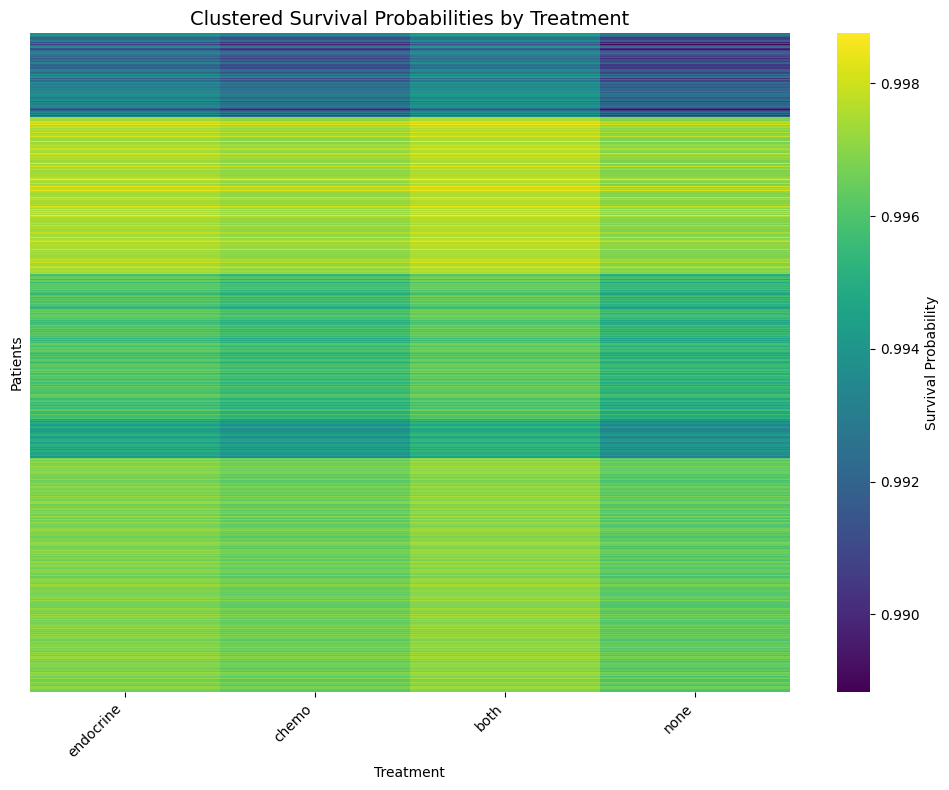

In [114]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import AgglomerativeClustering
import numpy as np

def plot_clustered_treatment_heatmap(survival_probabilities):
    """
    Plots a clustered heatmap of survival probabilities by treatment.

    Args:
        survival_probabilities (pd.DataFrame): DataFrame with survival probabilities for each treatment and a 'best_treatment' column.
    """

    # Select the columns of interest for clustering
    best_outcome_heat = survival_probabilities.iloc[:, :4].copy()  # Remove "best_treatment" column
    # Ensure that we have only numerical values
    best_outcome_matrix = best_outcome_heat.values #Convert to Numerical for Cluster and see its effects, the clustering won't work if you dont use it

    # Perform Agglomerative Clustering
    n_clusters = 5  # You can experiment with different numbers of clusters
    cluster = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward', metric='euclidean')#Set the model
    cluster_labels = cluster.fit_predict(best_outcome_matrix)
    # Reorder data based on clusters (using indices)
    idx = np.argsort(cluster_labels) # Get indeces in the order based on cluster
    # Reorder matrix so it fits the correct sample
    best_outcome_matrix = best_outcome_matrix[idx]
    #Create heatmap,
    cluster_survival = pd.DataFrame(best_outcome_matrix, index= survival_probabilities.index[idx] , columns = survival_probabilities.columns[:4])
    # Plot heatmap
    plt.figure(figsize=(10, 8)) # Adjusted figure size
    sns.heatmap(cluster_survival, cmap='viridis', cbar_kws={'label': 'Survival Probability'})# sns is better to plot, but plt is ok
    plt.yticks([])
    plt.xticks(rotation=45, ha="right")  # Rotated x-axis labels
    plt.xlabel('Treatment')
    plt.ylabel('Patients')
    plt.title('Clustered Survival Probabilities by Treatment', fontsize=14)
    plt.tight_layout()
    plt.show()

#testing
plot_clustered_treatment_heatmap(best_outcome)

In [84]:
best_outcome['best_treatment'].value_counts()

best_treatment
both    853
Name: count, dtype: int64

Patient 1 - Cumulative Hazard Function: StepFunction(x=array([  56.,   59.,  136., ..., 2472., 2473., 2474.]), y=array([0.00024788, 0.00024788, 0.00049604, ..., 0.10772814, 0.10772814,
       0.10772814]), a=np.float64(0.9801205199541378), b=0.0)
Patient 2 - Cumulative Hazard Function: StepFunction(x=array([  56.,   59.,  136., ..., 2472., 2473., 2474.]), y=array([0.00024788, 0.00024788, 0.00049604, ..., 0.10772814, 0.10772814,
       0.10772814]), a=np.float64(0.3422403606221743), b=0.0)
Patient 3 - Cumulative Hazard Function: StepFunction(x=array([  56.,   59.,  136., ..., 2472., 2473., 2474.]), y=array([0.00024788, 0.00024788, 0.00049604, ..., 0.10772814, 0.10772814,
       0.10772814]), a=np.float64(0.8826012879765498), b=0.0)
Patient 4 - Cumulative Hazard Function: StepFunction(x=array([  56.,   59.,  136., ..., 2472., 2473., 2474.]), y=array([0.00024788, 0.00024788, 0.00049604, ..., 0.10772814, 0.10772814,
       0.10772814]), a=np.float64(1.1189853925357296), b=0.0)
Patient 5 - 

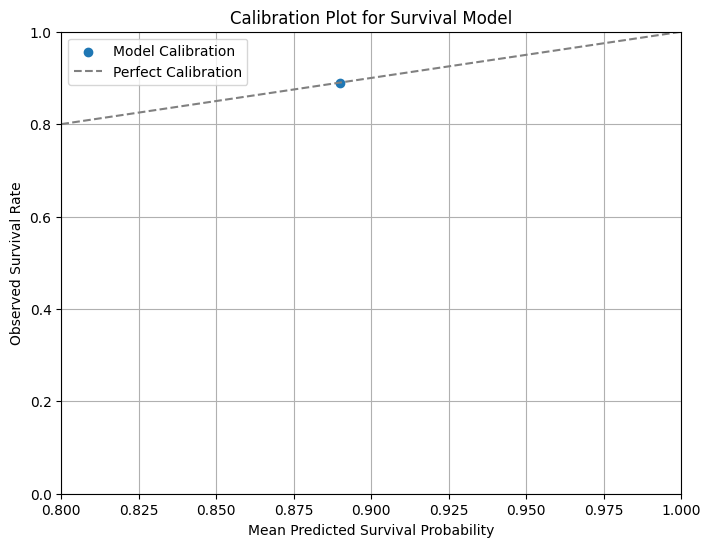

In [85]:
import numpy as np
import matplotlib.pyplot as plt


time = 3650  # 10 years in days
# 1. Predict Survival Probabilities (as described above)
cumulative_hazard_functions = cox_model.predict_cumulative_hazard_function(X_test)
predict = cox_model.predict(X_test)
survival_probabilities = []
for i, chf in enumerate(cumulative_hazard_functions):
    print(f"Patient {i+1} - Cumulative Hazard Function: {chf}")
    try:
        # chf.x is the times at which the function has steps
        # chf.y is the value of the function at each time step
        time_index = np.searchsorted(chf.x, time, side="right") - 1  # Find the index just before time
        if time_index >= 0:
            cumulative_hazard = chf.y[time_index]
        else:
            cumulative_hazard = 0  # Handle cases where 365 is before the first step
    except Exception as e:
        cumulative_hazard = chf(time)  # Evaluate the function at time
    survival_probabilities.append(np.exp(-cumulative_hazard))

survival_probabilities = np.array(survival_probabilities)

# 2. Binning - Adjusted for Probabilities Around 0.9
n_bins = 10
bin_start = 0.8  # Start binning at 0.8
bin_end = 1.0    # End binning at 1.0
bins = np.linspace(bin_start, bin_end, n_bins + 1) # Focus bins on the 0.8-1.0 range
binned_predictions = np.digitize(survival_probabilities, bins) - 1  # Subtract 1 to get 0-based bin indices

# 3. Calculate Observed Survival Rates
observed_survival_rates = []
bin_midpoints = []

for i in range(n_bins):
    # Find patients that fall into bin i
    patients_in_bin = (binned_predictions == i)
    n_patients_in_bin = np.sum(patients_in_bin)

    if n_patients_in_bin > 0:
        #calculate survival based on real data, so
        # y_test_survival['overall survival event'] -> True if the patient died
        # y_test_survival['overall survival days'] -> Time untill dead
        # The survivals are the patients that overall survival days>365 or that they didn't died (overall survival event is False)
        # so the final patients_survived is (y_test_survival['overall survival days']>365) | (y_test_survival['overall survival event']==False)
        patients_survived = ((y_test['overall survival days']>time) | (y_test['overall survival event']==False))[patients_in_bin]
        #Patients survived
        n_survived = np.sum(patients_survived)

        observed_survival_rate = n_survived / n_patients_in_bin
        observed_survival_rates.append(observed_survival_rate)
        bin_midpoints.append((bins[i] + bins[i+1]) / 2)
    else:
        # Avoid empty bins
        observed_survival_rates.append(np.nan)
        bin_midpoints.append((bins[i] + bins[i + 1]) / 2)  # Still keep the midpoint for consistency

# 4. Plot the Calibration Curve
plt.figure(figsize=(8, 6))
valid_bins = ~np.isnan(observed_survival_rates)  # Filter out NaN values
plt.scatter(np.array(bin_midpoints)[valid_bins], np.array(observed_survival_rates)[valid_bins], label="Model Calibration")
plt.plot([bin_start, bin_end], [bin_start, bin_end], linestyle="--", color="gray", label="Perfect Calibration")  # Diagonal line
plt.xlabel("Mean Predicted Survival Probability")
plt.ylabel("Observed Survival Rate")
plt.title("Calibration Plot for Survival Model")
plt.xlim([bin_start, bin_end])  # Adjust x-axis limits
plt.ylim([0, 1])
plt.legend()
plt.grid(True)
plt.show()

In [86]:
predict

array([-2.00797353e-02, -1.07224198e+00, -1.24881723e-01,  1.12422375e-01,
       -1.20481585e+00,  3.78840644e-01, -3.19401621e-01, -8.31838195e-02,
       -3.56012562e-01,  3.86119009e-01, -2.40866765e-01, -3.78106089e-01,
        1.13838120e+00, -4.87160597e-02,  2.14393291e-01,  1.48326246e+00,
       -2.80476781e-01, -3.57114101e-02,  1.62066304e-01,  6.90098861e-05,
       -1.40804011e+00,  1.62123234e-01, -1.42485017e+00,  7.03931402e-01,
        2.05276964e-01,  7.86181298e-01, -8.60755716e-01, -1.80573174e-02,
       -7.16184744e-01,  7.34145418e-01, -8.94493300e-01,  1.45578999e-01,
       -5.58068295e-02, -1.69474589e-02, -4.93826474e-01,  1.27387856e+00,
        1.61848298e-01, -8.76639389e-01, -3.50334451e-01, -3.40164054e-01,
        1.73586592e+00, -2.40924255e-02, -9.15450835e-01, -1.72903808e-01,
        1.12283122e+00,  1.16171124e+00,  1.67454894e-01, -3.13365296e-01,
        1.24243489e+00, -1.23556346e+00, -1.07730070e+00, -3.40221025e-02,
       -6.92446456e-02, -

In [87]:
print("X_train min/max after scaling:")
for col in X_train.columns:
    if X_train[col].dtype in ['float64', 'int64']:
        print(f"{col}: min={X_train[col].min():.4f}, max={X_train[col].max():.4f}")

print("\nX_test min/max after scaling:")
for col in X_test.columns:
    if X_test[col].dtype in ['float64', 'int64']:
        print(f"{col}: min={X_test[col].min():.4f}, max={X_test[col].max():.4f}")



X_train min/max after scaling:
age at diagnosis: min=-2.9518, max=2.5252
tumor size: min=-1.6672, max=8.9441
lymph node group: min=-2.3780, max=1.7199
lymph node status: min=-2.5160, max=1.2847
pam50 subtype: min=-2.0393, max=1.9556

X_test min/max after scaling:
age at diagnosis: min=-2.9518, max=2.4491
tumor size: min=-1.6672, max=8.4388
lymph node group: min=-2.3780, max=1.7199
lymph node status: min=-2.5160, max=1.2847
pam50 subtype: min=-2.0393, max=1.9556


In [88]:
model_coed_df = pd.DataFrame(cox_model.coef_).T
model_coed_df.columns = X_train.columns


In [89]:
model_coed_df.head()

,age at diagnosis,tumor size,lymph node group,lymph node status,er status,pgr status,her2 status,ki67 status,nhg,pam50 subtype,endocrine treated,chemo treated
0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.004643,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.009452,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.014431,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.019583,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


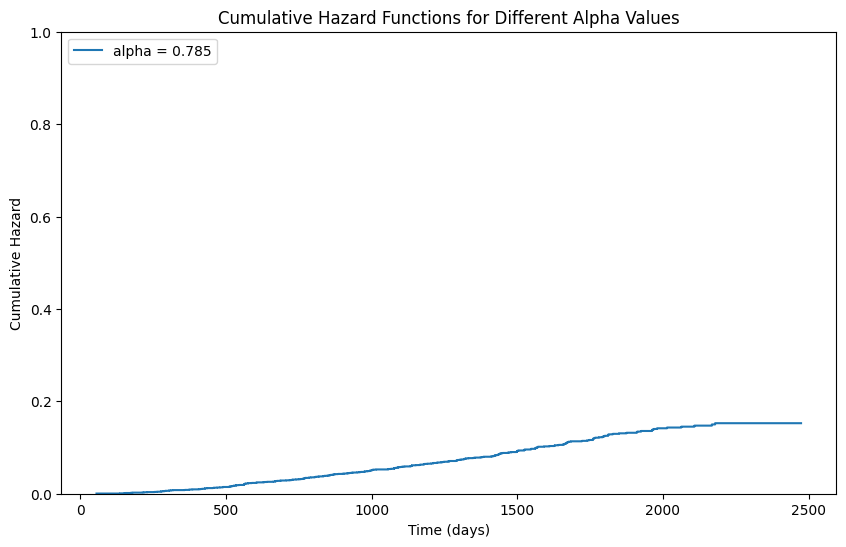

In [95]:
import matplotlib.pyplot as plt
import pandas as pd
from sksurv.functions import StepFunction

def plot_cumulative_hazard_functions(estimator, X, max_plots = 1):
  """Plots the cumulative hazard functions for different alpha values.

  Args:
      estimator: A fitted CoxnetSurvivalAnalysis model.
      X: Data used for prediction (ideally a subset for clarity).
      max_plots: The maximum number of plots.
  """
  chf_funcs = {}
  alphas_to_plot = estimator.alphas_[:min(max_plots, len(estimator.alphas_))] # Select the number of alpha we have
  for alpha in alphas_to_plot:
      chf_funcs[alpha] = estimator.predict_cumulative_hazard_function(
          X, alpha=alpha)

  # Plot the estimated cumulative hazard functions
  plt.figure(figsize=(10, 6)) # Adjust size for better viewing
  for alpha, chf_alpha in chf_funcs.items():
      for fn in chf_alpha:
          # Ensure that chf_alpha is a StepFunctions object
          if isinstance(fn, StepFunction):
            plt.step(fn.x, fn.y, where="post",
                     label=f"alpha = {alpha:.3f}")
          else:
            times = np.linspace(X['age at diagnosis'].min(), X['age at diagnosis'].max(), num=100)
            plt.step(times, chf_alpha(times), where="post",
                     label=f"alpha = {alpha:.3f}")

  plt.ylim(0, 1)
  plt.xlabel("Time (days)")
  plt.ylabel("Cumulative Hazard")
  plt.title("Cumulative Hazard Functions for Different Alpha Values")
  plt.legend(loc='upper left')
  plt.show()

#call Function
i = 0

plot_cumulative_hazard_functions(cox_model, X_test.iloc[[i]])

In [103]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sksurv.functions import StepFunction

def plot_cumulative_hazard_functions(estimator, X, max_plots=5, days=365,  time_zoom=0.3):
    """Plots the cumulative hazard functions for different alpha values and multiple patients.

    Args:
        estimator: A fitted CoxnetSurvivalAnalysis model.
        X: Data used for prediction (ideally a subset for clarity).
        max_plots: The maximum number of alpha values to plot.
        time_zoom: Max value to use for the plot, cumulative hazard from 0 to that value
    """
    num_samples = min(10, len(X)) 
    chf_funcs = {}
    alphas_to_plot = estimator.alphas_[:1]  # Select alpha values to plot
    alpha =0 
    # Select feature names based on the indices

    for sample in range(num_samples):
        chf_funcs[0] = estimator.predict_cumulative_hazard_function(
            X.iloc[:sample], alpha=0)

    # Plot the estimated cumulative hazard functions
    plt.figure(figsize=(12, 8))  # Adjust size for better viewing
    for i in range(num_samples):  # Iterate through patients
        for alpha, chf_alpha in chf_funcs.items():
          # Ensure that chf_alpha is a StepFunctions object
          if isinstance(chf_alpha[i], StepFunction):
            #Ensure the time Zoom is higher than the max value, if not, plot everything 
            if (max(chf_alpha[i].y))<=time_zoom:
              print("Values bigger than time_zoom, plotting with all of them")
              plt.step(chf_alpha[i].x, chf_alpha[i].y, where="post",
                      label=f"Patient {i+1}, alpha = {alpha:.3f}")  # Include patient label
          else:
              times = np.linspace(100, 2000, num=100)
              plt.step(times, chf_alpha[i](times), where="post",
                       label=f"Patient {i+1}, alpha = {alpha:.3f}")  # Include patient label
            
    plt.ylim(0, time_zoom)
    plt.xlabel("Time (days)")
    plt.ylabel("Cumulative Hazard")
    plt.title("Cumulative Hazard Functions for Different Alpha Values (Multiple Patients)")
    # Use a single legend outside the loop
    plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
    plt.tight_layout(rect=[0, 0, 1, 0.95]) # Adjust layout to fit legend
    plt.show()
i = 0
#Test
plot_cumulative_hazard_functions(estimator=cox_model, X=X_test.iloc[:10],days=2, max_plots=1, time_zoom=.2)

ValueError: alpha must be one value of alphas_: [0.78494066 0.7492639  0.7152087  0.68270136 0.65167153 0.62205205
 0.59377882 0.56679066 0.54102915 0.51643854 0.49296561 0.47055956
 0.44917191 0.42875635 0.40926871 0.39066682 0.37291041 0.35596105
 0.33978207 0.32433845 0.30959677 0.29552512 0.28209305 0.26927148
 0.25703268 0.24535015 0.2341986  0.22355392 0.21339305 0.203694
 0.1944358  0.18559839 0.17716265 0.16911034 0.16142401 0.15408704
 0.14708355 0.14039837 0.13401705 0.12792577 0.12211135 0.1165612
 0.11126331 0.10620622 0.10137898 0.09677115 0.09237276 0.08817427
 0.08416661 0.08034111 0.07668948 0.07320383 0.0698766  0.0667006
 0.06366896 0.0607751  0.05801278 0.05537601 0.05285909 0.05045656
 0.04816323 0.04597414 0.04388454 0.04188992 0.03998596 0.03816854
 0.03643372 0.03477775 0.03319705 0.03168819 0.03024791 0.0288731
 0.02756077 0.02630809 0.02511235 0.02397095 0.02288144 0.02184144
 0.02084871 0.01990111 0.01899657 0.01813315 0.01730897 0.01652225
 0.01577129 0.01505

These are the top coefficients to evaluate: [0.00784941 0.00822316]
Len of chf: 500
Patient 1 - Cumulative Hazard Function: StepFunction(x=array([  56.,   59.,  136., ..., 2472., 2473., 2474.]), y=array([0.00024788, 0.00024788, 0.00049604, ..., 0.10772814, 0.10772814,
       0.10772814]), a=np.float64(0.9801205199541378), b=0.0)
Patient 2 - Cumulative Hazard Function: StepFunction(x=array([  56.,   59.,  136., ..., 2472., 2473., 2474.]), y=array([0.00024788, 0.00024788, 0.00049604, ..., 0.10772814, 0.10772814,
       0.10772814]), a=np.float64(0.3422403606221743), b=0.0)
Patient 3 - Cumulative Hazard Function: StepFunction(x=array([  56.,   59.,  136., ..., 2472., 2473., 2474.]), y=array([0.00024788, 0.00024788, 0.00049604, ..., 0.10772814, 0.10772814,
       0.10772814]), a=np.float64(0.8826012879765498), b=0.0)
Patient 4 - Cumulative Hazard Function: StepFunction(x=array([  56.,   59.,  136., ..., 2472., 2473., 2474.]), y=array([0.00024788, 0.00024788, 0.00049604, ..., 0.10772814, 0.

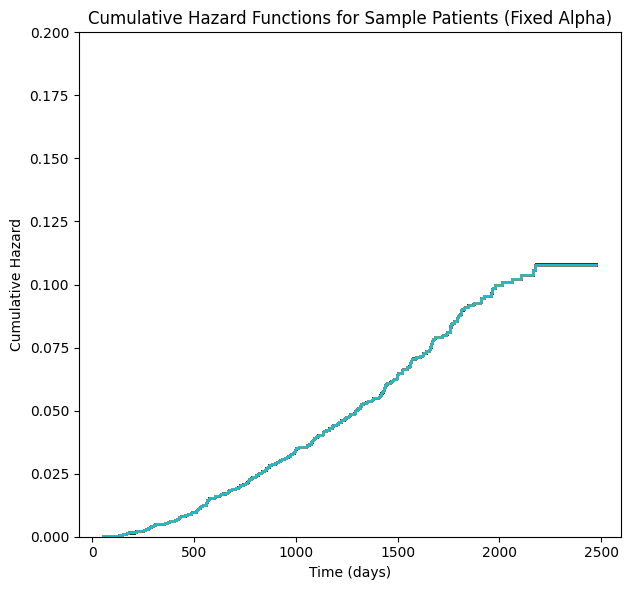

In [111]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sksurv.functions import StepFunction

def plot_chf_for_samples(estimator, X,num_patients=5,time=365):
    """Plots cumulative hazard functions for multiple patients at a fixed alpha,
       and plot distributions for the feature

    Args:
        estimator: A fitted CoxnetSurvivalAnalysis model.
        X: Data used for prediction
        alphas_idx: Position to search for the coeficient
    """

    num_samples = min(num_patients, len(X))  # Ensure we don't exceed available samples
    #This parameters can be tunned
    # Select the alpha that has most weight and second to evaluate it
    chosen_alphas_index = np.argsort(np.abs(estimator.coef_[-1]))[::-1][:2]
    print (f"These are the top coefficients to evaluate: {estimator.alphas_[chosen_alphas_index]}")
    # Set number of alpha equal to the coeff size
    first_chosen_alpha = estimator.alphas_[chosen_alphas_index][0]
    second_chosen_alpha = estimator.alphas_[chosen_alphas_index][1]
    #Get the CH
    chf = estimator.predict_cumulative_hazard_function(X.iloc[:num_samples], alpha=first_chosen_alpha)
    print(f"Len of chf: {len(chf)}")
    chf_secondary = estimator.predict_cumulative_hazard_function(X.iloc[:num_samples], alpha=second_chosen_alpha)
    # Plotting
    plt.figure(figsize=(12, 6))

    #Plotting The cumulatative Hazard function
    plt.subplot(1, 2, 1)  # Create two subplots side by side
    for i in range(num_samples):
        if isinstance(chf[i], StepFunction):
            plt.step(chf[i].x, chf[i].y, where="post",
                     label=f"Patient {i+1}, alpha={first_chosen_alpha:.3f}")
            print(f"Patient {i+1} - Cumulative Hazard Function: {chf[i]}")
            
    plt.ylim(0, 0.2)
    plt.xlabel("Time (days)")
    plt.ylabel("Cumulative Hazard")
    plt.title("Cumulative Hazard Functions for Sample Patients (Fixed Alpha)")
    #plt.legend(loc = 'upper left')
    plt.tight_layout() # Adjust layout to fit legend
#Testing
plot_chf_for_samples(cox_model, X_test, num_patients=500)

In [106]:
chf

StepFunction(x=array([  56.,   59.,  136., ..., 2472., 2473., 2474.]), y=array([0.00024788, 0.00024788, 0.00049604, ..., 0.10772814, 0.10772814,
       0.10772814]), a=np.float64(1.9038800950449581), b=0.0)